# Alpha 能损：MLP 回归顶点动能

**功能**：读取当前目录 `Processd.root/tree`，以 13 个探测器能量与世界坐标特征预测 `KinematicsAtVertex`（MeV）。

**方法**：uproot / awkward → NumPy float64 → 80%/20% 事件划分 → 训练集归一化 → PyTorch float64 MLP → 固定轮数训练 → 测试损失监控与误差评估。

**注意事项**：每行对应 PreProcess.C 筛出的一个事件。四层 SSD 的位置和顶点均为模拟真值，这是一项真值条件下的能量回归测试。模型直接预测 alpha 的顶点总动能，既不是 MeV/u，也不把标签替换成能量差。SSD X1、Y1、X2、Y2 是四个不同物理平面，各自保留 Z。主 GAGG 与 DeltaE 能量分别输入。

依赖：`uproot`、`awkward`、`numpy`、`torch`、`matplotlib`。CUDA 可用时加速；MPS 不支持 float64，此 Notebook 保持精度并使用 CPU。

本文件交付时没有执行任何单元。参考仅取自本地 `nndl-practice/pytorch/chap4前馈神经网络/前馈神经网络-上.ipynb`、`nndl/runner.py` 及 machine-learning skill 的 `references/pytorch-examples/basics/regression/main.py`；不需要导入这些参考文件。

单元格内容参考用户指定的 `/Users/yemingxin/nptool/Projects/myTOGAXSI_ppalpha/RungeKutta/MachineLeaning/ThinTarget/InverseThinTarget.ipynb`：训练流程参考 SmoothL1(beta=0.01)，batch size 256，Adam、2000 epoch、余弦退火、梯度裁剪。参考中的 float32/MPS 改为本任务要求的 float64/CUDA 或 CPU。

仅有训练集和用户称为测试集的 20% 留出数据；后者逐轮监控损失，在统计意义上承担验证作用。这里不据其损失早停或选择权重，使用固定轮数的最终模型。若据曲线进一步调整超参数，所报告误差不是完全独立的最终测试误差。

## 1. 导入、固定随机数及输入配置
网络结构在模型单元显式定义；训练轮数及优化参数在训练单元定义。

In [1]:
# 功能：配置 ROOT→MLP 回归；方法：固定种子和 float64；注意事项：本单元不读取或写入数据。
from pathlib import Path
import random
import awkward as ak
import numpy as np
import torch
import torch.nn as nn
import uproot
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset

ROOT_PATH = Path("Processd.root")
TREE_NAME = "tree"
OUTPUT_DIR = Path("EnergyLoss_output")
FEATURE_NAMES = [
    "ClusterGAGGEnergy", "DeltaEGAGGEnergy",
    "ClusterSSDX1", "ClusterSSDY1", "ClusterSSDX2", "ClusterSSDY2",
    "ClusterSSDZX1", "ClusterSSDZY1", "ClusterSSDZX2", "ClusterSSDZY2",
    "VertexX", "VertexY", "VertexZ",
]
FEATURE_UNITS = ["MeV", "MeV"] + ["mm"] * 11
TARGET_NAME = "KinematicsAtVertex"
SEED = 42
DTYPE = torch.float64

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.set_default_dtype(DTYPE)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    device = torch.device("cuda")
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True
elif torch.backends.mps.is_available():
    device = torch.device("cpu")
    print("MPS 可用但不支持 float64；为保持精度，使用 CPU。")
else:
    device = torch.device("cpu")
print("Device:", device, "dtype:", DTYPE)
print("Input:", ROOT_PATH.resolve())

MPS 可用但不支持 float64；为保持精度，使用 CPU。
Device: cpu dtype: torch.float64
Input: /Users/yemingxin/ROOT_Exercise/MachineLearning/EnergyLoss/Processd.root


## 2. 读取 ROOT 并检查事件对齐
只读取指定 13 个输入和一个标签。所有分支必须是等长的一维标量，每行保持同一 ROOT entry 的对应关系。发现 NaN、Inf、`-999` 或非物理能量时直接报错，不静默删行，也不引入新的物理筛选。

`Processd.root` 不含原始 EventID；使用处理后树的 entry index 标记行。随机划分成立的前提是预处理保持每个原始事件最多一行；若以后改成多条候选，必须保存原始 EventID 并按事件划分。

In [2]:
branches = FEATURE_NAMES + [TARGET_NAME]
with uproot.open(ROOT_PATH) as root_file:
    tree = root_file[TREE_NAME]
    missing = [name for name in branches if name not in tree.keys()]
    if missing:
        raise KeyError(f"缺失分支: {missing}")
    entry_count = tree.num_entries
    arrays = tree.arrays(branches, library="ak", how=dict)

columns = {}
for name in branches:
    column = np.asarray(ak.to_numpy(arrays[name]), dtype=np.float64)
    if column.ndim != 1 or len(column) != entry_count:
        raise ValueError(f"{name} 必须是每事件一个标量，实际 shape={column.shape}")
    bad = ~np.isfinite(column) | (column == -999.0)
    if np.any(bad):
        raise ValueError(f"{name} 含无效值，entry 示例: {np.flatnonzero(bad)[:10]}")
    columns[name] = column

X = np.column_stack([columns[name] for name in FEATURE_NAMES]).astype(np.float64)
y = columns[TARGET_NAME].reshape(-1, 1)
entry_index = np.arange(entry_count, dtype=np.int64)
if entry_count < 20:
    raise ValueError("事件太少，无法建立有效的训练/验证/测试划分。")
if np.any(X[:, 0] <= 0) or np.any(X[:, 1] < 0) or np.any(y <= 0):
    raise ValueError("主 GAGG 与标签须大于 0，DeltaE 能量须大于等于 0。")
print("X:", X.shape, X.dtype, "y:", y.shape, y.dtype)
for name in branches:
    print(f"{name:22s}: min={columns[name].min():.6g}, max={columns[name].max():.6g}")

X: (27210, 13) float64 y: (27210, 1) float64
ClusterGAGGEnergy     : min=0.596034, max=502.364
DeltaEGAGGEnergy      : min=178.239, max=599.554
ClusterSSDX1          : min=-74.1887, max=77.4905
ClusterSSDY1          : min=-33.1387, max=35.6056
ClusterSSDX2          : min=-86.5692, max=90.7904
ClusterSSDY2          : min=-37.3367, max=40.9405
ClusterSSDZX1         : min=226.75, max=226.844
ClusterSSDZY1         : min=231.25, max=231.295
ClusterSSDZX2         : min=285.45, max=285.45
ClusterSSDZY2         : min=289.95, max=290.037
VertexX               : min=-15.4413, max=15.4991
VertexY               : min=-15.4952, max=15.4527
VertexZ               : min=-74.999, max=74.9867
KinematicsAtVertex    : min=473.737, max=777.455


## 3. 划分与训练集归一化
输入与标签都标准化；均值和标准差只从训练集计算。常量列的缩放量设为 1，不删掉用户指定特征。预测时按相同参数转换回 MeV。

In [3]:
# 与参考 Notebook 一致：独立 CPU 随机生成器固定划分索引。
split_generator = torch.Generator(device="cpu").manual_seed(SEED)
indices = torch.randperm(entry_count, generator=split_generator).numpy()
n_train = int(0.80 * entry_count)
train_idx = indices[:n_train]
test_idx = indices[n_train:]
assert len(np.unique(np.concatenate([train_idx, test_idx]))) == entry_count

X_train, y_train = X[train_idx], y[train_idx]
X_test, y_test = X[test_idx], y[test_idx]
x_mean = X_train.mean(axis=0)
x_std_raw = X_train.std(axis=0)
x_std = np.where(x_std_raw == 0.0, 1.0, x_std_raw)
y_mean = y_train.mean(axis=0)
y_std = y_train.std(axis=0)
if np.any(y_std == 0.0):
    raise ValueError("训练标签为常量，不能评估能量回归能力。")
print("Constant features:", [FEATURE_NAMES[i] for i in np.flatnonzero(x_std_raw == 0)])
X_train_n = (X_train - x_mean) / x_std
X_test_n = (X_test - x_mean) / x_std
y_train_n = (y_train - y_mean) / y_std
y_test_n = (y_test - y_mean) / y_std
print(f"Train / test: {len(train_idx)} / {len(test_idx)}")
print("Training target mean/std (MeV):", y_mean, y_std)

Constant features: []
Train / test: 21768 / 5442
Training target mean/std (MeV): [691.9785149] [39.68242796]


## 4. 张量与 MLP
网络为用户指定的 `13→64→64→64→1`，三个隐藏层用 Tanh，输出层为线性层。所有张量与模型保持 float64 和一致的 device。

In [4]:
def to_tensor(array):
    return torch.from_numpy(np.ascontiguousarray(array, dtype=np.float64)).to(
        device=device, dtype=DTYPE
    )

X_train_t, y_train_t = to_tensor(X_train_n), to_tensor(y_train_n)
X_test_t, y_test_t = to_tensor(X_test_n), to_tensor(y_test_n)

# 显式定义 13 -> 64 -> 64 -> 64 -> 1，三个隐藏层使用 Tanh。
def build_model():
    return nn.Sequential(
        nn.Linear(13, 64), nn.Tanh(),
        nn.Linear(64, 64), nn.Tanh(),
        nn.Linear(64, 64), nn.Tanh(),
        nn.Linear(64, 1),
    )

print(build_model())

Sequential(
  (0): Linear(in_features=13, out_features=64, bias=True)
  (1): Tanh()
  (2): Linear(in_features=64, out_features=64, bias=True)
  (3): Tanh()
  (4): Linear(in_features=64, out_features=64, bias=True)
  (5): Tanh()
  (6): Linear(in_features=64, out_features=1, bias=True)
)


## 5. 固定轮数训练与完整集合损失监控
参考指定 Notebook：每次执行本单元重新初始化模型、优化器、学习率调度器和 DataLoader 随机生成器。固定训练 2000 epoch；不早停，不选择测试损失最小的权重。

每轮 batch 更新结束后，用相同模型状态在 `eval()` / `no_grad()` 下重新计算完整训练集和完整测试集的损失。记录梯度裁剪前范数及学习率用于诊断。测试损失只用于显示曲线。

In [5]:
# 训练参数在训练单元内显式定义，与参考 Notebook 的安排一致。
LEARNING_RATE = 1e-3
MINIMUM_LEARNING_RATE = 1e-5
GRADIENT_CLIP_NORM = 1.0
epoch_count = 2000
BATCH_SIZE = 256
WEIGHT_DECAY = 0.0
SMOOTH_L1_BETA = 0.01  # 作用于标准化标签残差，不是 0.01 MeV。

# 重新执行本单元将从固定种子和全新的优化器状态开始训练。
torch.manual_seed(SEED)
if device.type == "cuda":
    torch.cuda.manual_seed_all(SEED)
model = build_model().to(device=device, dtype=DTYPE)
criterion = nn.SmoothL1Loss(beta=SMOOTH_L1_BETA)
optimizer = torch.optim.Adam(
    model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY
)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=epoch_count, eta_min=MINIMUM_LEARNING_RATE
)
loader_generator = torch.Generator(device="cpu").manual_seed(SEED)
train_loader = DataLoader(
    TensorDataset(X_train_t.detach().cpu(), y_train_t.detach().cpu()),
    batch_size=BATCH_SIZE, shuffle=True, generator=loader_generator,
    num_workers=0, drop_last=False,
)

train_loss_history, test_loss_history = [], []
gradient_norm_history, learning_rate_history = [], []
for epoch in range(1, epoch_count + 1):
    model.train()
    gradient_norm_sum = 0.0
    batch_count = 0
    for xb, yb in train_loader:
        xb = xb.to(device=device, dtype=DTYPE)
        yb = yb.to(device=device, dtype=DTYPE)
        optimizer.zero_grad(set_to_none=True)
        loss = criterion(model(xb), yb)
        if not torch.isfinite(loss).item():
            raise RuntimeError("训练损失出现 NaN/Inf。")
        loss.backward()
        gradient_norm = nn.utils.clip_grad_norm_(
            model.parameters(), GRADIENT_CLIP_NORM, error_if_nonfinite=True
        )
        optimizer.step()
        gradient_norm_sum += float(gradient_norm.detach().cpu())
        batch_count += 1

    model.eval()
    with torch.no_grad():
        train_loss = criterion(model(X_train_t), y_train_t).item()
        test_loss = criterion(model(X_test_t), y_test_t).item()
    if not np.isfinite(train_loss) or not np.isfinite(test_loss):
        raise RuntimeError("完整集合评估损失出现 NaN/Inf。")
    train_loss_history.append(train_loss)
    test_loss_history.append(test_loss)
    gradient_norm_history.append(gradient_norm_sum / batch_count)
    learning_rate_history.append(optimizer.param_groups[0]["lr"])
    scheduler.step()
    if epoch == 1 or epoch % 100 == 0:
        print(f"Epoch {epoch:4d}/{epoch_count}: train={train_loss:.6g}, "
              f"test={test_loss:.6g}, gradient norm={gradient_norm_history[-1]:.6g}, "
              f"lr={learning_rate_history[-1]:.2e}")

epoch_count = len(train_loss_history)
model.eval()
print(f"Finished {epoch_count} epochs; using final model weights.")

Epoch    1/2000: train=0.228684, test=0.220547, gradient norm=0.521897, lr=1.00e-03
Epoch  100/2000: train=0.043453, test=0.043485, gradient norm=2.21551, lr=9.94e-04
Epoch  200/2000: train=0.0336112, test=0.034478, gradient norm=1.47811, lr=9.76e-04
Epoch  300/2000: train=0.0329953, test=0.0346346, gradient norm=1.37118, lr=9.46e-04
Epoch  400/2000: train=0.0336295, test=0.035868, gradient norm=1.07791, lr=9.06e-04
Epoch  500/2000: train=0.0286575, test=0.0307537, gradient norm=1.04669, lr=8.56e-04
Epoch  600/2000: train=0.0301016, test=0.0320573, gradient norm=0.838124, lr=7.97e-04
Epoch  700/2000: train=0.0292261, test=0.0314917, gradient norm=0.975047, lr=7.30e-04
Epoch  800/2000: train=0.0271233, test=0.0298432, gradient norm=0.858683, lr=6.59e-04
Epoch  900/2000: train=0.0274819, test=0.0314014, gradient norm=0.81166, lr=5.83e-04
Epoch 1000/2000: train=0.0266509, test=0.0304756, gradient norm=0.76706, lr=5.06e-04
Epoch 1100/2000: train=0.0261739, test=0.0297123, gradient norm=0.7

## 6. 单独绘制损失曲线
两条曲线均为每轮结束时同一模型状态下的完整集合损失，纵轴为标准化 SmoothL1 loss。

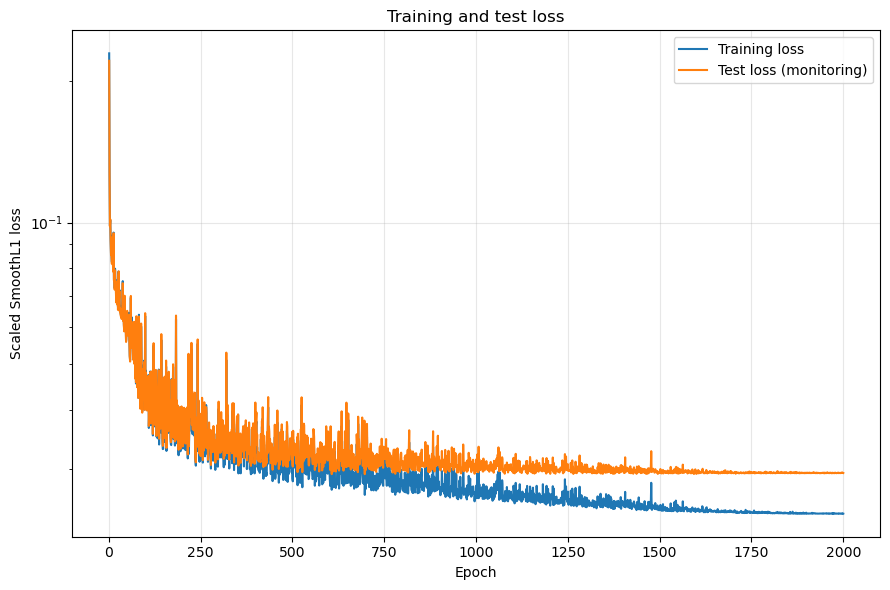

In [6]:
epochs = np.arange(1, epoch_count + 1)
fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(epochs, train_loss_history, label="Training loss")
ax.plot(epochs, test_loss_history, label="Test loss (monitoring)")
ax.set_yscale("log")
ax.set_xlabel("Epoch")
ax.set_ylabel("Scaled SmoothL1 loss")
ax.set_title("Training and test loss")
ax.grid(alpha=0.3)
ax.legend()
fig.tight_layout()
plt.show()

## 7. 固定轮数后的预测和残差（MeV）
残差定义为 **预测 − 真值**；报告 MSE、RMSE、MAE、R²、Bias 和残差标准差。20% 留出集合已经用于逐轮损失监控，此处指标描述该集合上的误差，不称为独立最终测试。

直接相加 `ClusterGAGGEnergy + DeltaEGAGGEnergy` 作为未补偿靶和 SSD 能损的基线，仅供对照，不参与训练。

残差直方图显示范围为 [-50, 50] MeV，bin 宽为 1 MeV；指标仍使用全部测试事件，范围外残差仅不显示在图中。

Test/monitoring events: 5442
MSE_MeV2             MLP=3.80105  energy-sum baseline=899.594
RMSE_MeV             MLP=1.94963  energy-sum baseline=29.9932
MAE_MeV              MLP=1.3528  energy-sum baseline=22.7183
R2                   MLP=0.997542  energy-sum baseline=0.418232
Bias_MeV             MLP=0.00568416  energy-sum baseline=-22.7128
ResidualStd_MeV      MLP=1.94962  energy-sum baseline=19.5888


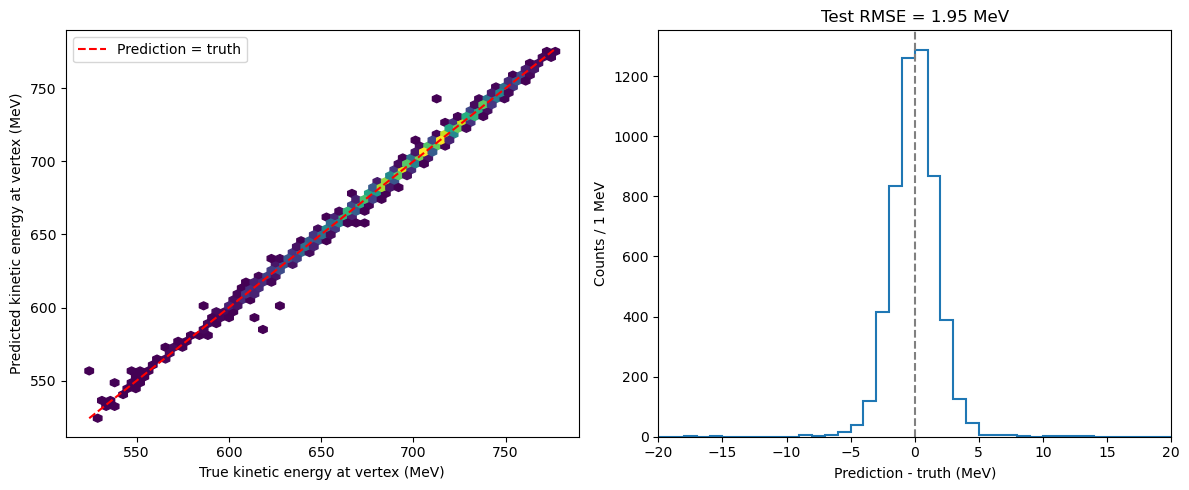

In [7]:
X_test_t = to_tensor(X_test_n)
model.eval()
with torch.no_grad():
    pred_n = model(X_test_t).cpu().numpy()
pred = pred_n * y_std + y_mean
if not np.all(np.isfinite(pred)):
    raise RuntimeError("测试预测包含 NaN/Inf。")
residual = pred - y_test

def regression_metrics(truth, prediction):
    difference = prediction - truth
    mse = float(np.mean(difference ** 2))
    ss_tot = float(np.sum((truth - truth.mean()) ** 2))
    r2 = np.nan
    if ss_tot > 0:
        r2 = 1.0 - float(np.sum(difference ** 2)) / ss_tot
    return {
        "MSE_MeV2": mse,
        "RMSE_MeV": float(np.sqrt(mse)),
        "MAE_MeV": float(np.mean(np.abs(difference))),
        "R2": r2,
        "Bias_MeV": float(difference.mean()),
        "ResidualStd_MeV": float(difference.std()),
    }

metrics = regression_metrics(y_test, pred)
energy_sum = X_test[:, :2].sum(axis=1, keepdims=True)
baseline_metrics = regression_metrics(y_test, energy_sum)
print(f"Test/monitoring events: {len(test_idx)}")
for name in metrics:
    print(f"{name:20s} MLP={metrics[name]:.6g}  energy-sum baseline={baseline_metrics[name]:.6g}")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].hexbin(y_test[:, 0], pred[:, 0], gridsize=55, mincnt=1, cmap="viridis")
lo = min(y_test.min(), pred.min())
hi = max(y_test.max(), pred.max())
axes[0].plot([lo, hi], [lo, hi], "r--", label="Prediction = truth")
axes[0].set_xlabel("True kinetic energy at vertex (MeV)")
axes[0].set_ylabel("Predicted kinetic energy at vertex (MeV)")
axes[0].legend()
residual_min, residual_max, residual_bin_width = -20.0, 20.0, 1.0
residual_bins = np.arange(residual_min, residual_max + residual_bin_width, residual_bin_width)
counts, bin_edges, _ = axes[1].hist(
    residual[:, 0], bins=residual_bins, histtype="step", linewidth=1.5
)
axes[1].set_xlim(residual_min, residual_max)
axes[1].set_xlabel("Prediction - truth (MeV)")
axes[1].set_ylabel(f"Counts / {bin_edges[1] - bin_edges[0]:.3g} MeV")
axes[1].axvline(0, color="gray", linestyle="--")
axes[1].set_title(f"Test RMSE = {metrics['RMSE_MeV']:.3g} MeV")
fig.tight_layout()
plt.show()

保存训练得到的模型

In [8]:
torch.save(
    {
        "model": model,
        "feature_names": FEATURE_NAMES,
        "x_mean": x_mean,
        "x_std": x_std,
        "y_mean": y_mean,
        "y_std": y_std,
    },
    "EnergyLoss_output/EnergyLossMLP.pt",
)

print("model has been saved")

model has been saved


RMSE容易受到少数极端离群点的影响，因为它是平方误差

MAE相比RMSE对少数离群点没那么敏感，MAE越小越好

Bias：有没有整体偏高或偏低，越接近0越好

$R^{2}$：模型解释了多少数据变化，越接近1越好